In [2]:
from utility import *
from scipy.linalg import lstsq
from matplotlib import cm
mpl.rcParams['lines.linewidth'] = 3.0
mpl.rcParams['lines.linestyle'] = 'dashed'
mpl.rcParams['lines.markersize'] = 6
mpl.rcParams['lines.marker'] = 'o'
np.set_printoptions(precision=3)




supersize=9
ncell = supersize**3
natoms = ncell * 5
temp_list = np.array([600,700,800,820,900, 1000])

## experimental value at room temperature. Ref: M. J. Haun, E. Furman, S. Jang, H. McKinstry, and L. Cross, J. Appl. Phys. 62, 3331 (1987).  Also the appendix of the textbook "The Physics of Ferroelectrics: A Modern Perspective" 
exp_V = 63.2e-30# m^3
exp_alpha_11 = -7.252e7 * exp_V  # m^8 J /C^4
exp_alpha_12 = 7.5e8 * exp_V # m^8 J /C^4
exp_alpha_111 = 2.606e8 * exp_V # m^12 J /C^6
exp_alpha_112 = 6.1e8 * exp_V # m^12 J /C^6
exp_alpha_123 = -37e8 * exp_V  # m^12 J /C^6
## convert to our unit
P_cut = 96 * 0.01 # C/m^2
meV2J = 1.602176634e-22  
exp_alpha_11 = exp_alpha_11 * P_cut**4 / meV2J 
exp_alpha_12 = exp_alpha_12 * P_cut**4 / meV2J
exp_alpha_111 = exp_alpha_111 * P_cut**6 / meV2J
exp_alpha_112 = exp_alpha_112 * P_cut**6 / meV2J
exp_alpha_123 = exp_alpha_123 * P_cut**6 / meV2J

print(exp_alpha_11, exp_alpha_12, exp_alpha_111, exp_alpha_112, exp_alpha_123)


-24.29681864884717 251.2770819999363 80.46527394101257 188.34925980052824 -1142.4463299376305


In [3]:
def process_data(temp, polar_cutoff=0.06 ,energy_cutoff=12 ):
    """
    energy_cutoff [meV]: the FES data with value above this cutoff will be disregarded since they are associated with underexplored regimes.
    """
    ## load sampling grid of P and the FES data
    polar = np.load('./data_storage/polar.npy')
    fes = np.load('./data_storage/fes3D{}K.npy'.format(temp))
    # funit =  kb* temp * 1000  # kbT/meV
    polar = polar / polar_cutoff
    n = int( np.round(polar.shape[0]**(1/3)  ))
    polar = polar.reshape(n,n,n,-1)
    fes = fes.reshape(n,n,n)
    fes -= fes.min() # shift to zero min
    #### get a sparser P grid and FES data
    px = polar[::2,::2,::2,0]
    py = polar[::2,::2,::2,1]
    pz = polar[::2,::2,::2,2]
    fes = fes[::2,::2,::2]
    #### Gather FES data for well-explored region
    proj = (px>=0)&(py>=0)&(pz>=0)&(py>=px)&(pz>=py) & (fes < energy_cutoff)
    px = px[proj]
    py = py[proj]
    pz = pz[proj]
    print('Extracted FES data on well-explored regime (cutoff={}meV). #data={}'.format(energy_cutoff, proj.sum()))
    fes = fes[proj]
    return px, py, pz, fes

#  Fitting LD paras with least square and plot error distribution. Here we let each LD coefficients depends linearly on temperature

=================processing data for T=600==============
Extracted FES data on well-explored regime (cutoff=12meV). #data=5115
=================processing data for T=700==============
Extracted FES data on well-explored regime (cutoff=12meV). #data=4986
=================processing data for T=800==============
Extracted FES data on well-explored regime (cutoff=12meV). #data=4411
=================processing data for T=820==============
Extracted FES data on well-explored regime (cutoff=12meV). #data=4223
=================processing data for T=900==============
Extracted FES data on well-explored regime (cutoff=12meV). #data=3303
=================processing data for T=1000==============
Extracted FES data on well-explored regime (cutoff=12meV). #data=2267
LD parameters coeficient for constant term:  [-1.116e+02 -1.487e+01 -4.783e+01  5.553e+01  4.315e+02  1.963e+03
 -1.673e+03 -2.389e+04 -1.463e+04]
LD parameters coeficient for linear-in-temperatyre term:  [ 1.351e-01 -4.374e-05  2.689e-0

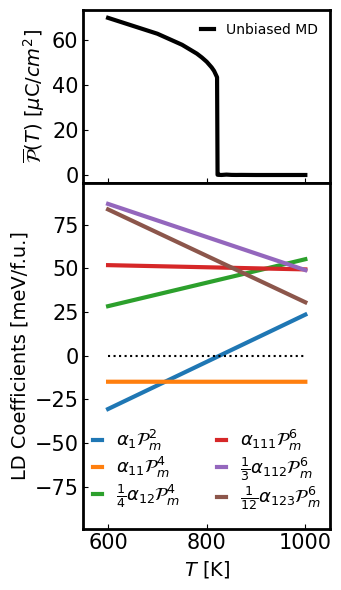

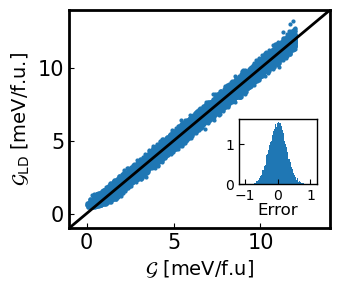

In [4]:
## MD polarization results
MD_temp = np.array([ 300, 400, 500, 600, 700, 750, 780, 790, 800, 810, 815, 820, 821, 822, 824, 825, 830, 840, 850, 860, 870, 900, 1000])
MD_polar = np.abs(np.array([ 8.35304062e+01,  7.97168887e+01,  7.53031657e+01,  6.99467084e+01,
  6.28793798e+01,  5.79680435e+01,  5.40223568e+01,  5.23375728e+01,
  5.04064450e+01,  4.79035754e+01,  4.63175593e+01,  4.39782179e+01,
  4.34744606e+01, -1.11593031e-01,  1.69642543e-01, -8.34173271e-02,
 -3.26012203e-02,  1.91944331e-01,  6.41566846e-02,  3.45276529e-02,
  5.93344612e-02, -1.54916488e-02,  2.24279864e-02]))

mpl.rcParams['axes.linewidth'] = 2.0 #set the value globally
norder = 2
fes_data_all = []
fes_fit_all = []
M_list =[]
ndata_list = []
for idx, temp in enumerate(temp_list):
    print('=================processing data for T={}=============='.format(temp))
    ## load data
    px, py, pz, fes =  process_data(temp, polar_cutoff=0.06 )
    ndata_list.append(fes.shape[0])
    ## preprocess
    X = []
    X.append(px**2 + py**2 + pz**2)  # a1
    X.append(px**4 + py**4 + pz**4)  # a11
    X.append(px**2*py**2 + px**2*pz**2 + py**2*pz**2) #a12
    X.append(px**6 + py**6 + pz**6)  #a111
    X.append(px**4*(py**2+pz**2) + py**4*(pz**2+px**2) + pz**4*(px**2+py**2)) # a112
    X.append(px**2*py**2*pz**2)  #a123
    ## lazy workaround for getting rid of redundancy in the zero of energy
    X.append(np.ones_like(px))
    X.append(np.ones_like(px)* (temp/1000)**norder) 
    X.append(np.ones_like(px)* (temp/1000)**(norder*2)) 
    
    nterms = len(X)
    M = np.array(X).reshape(nterms,-1).transpose()   ## (#data,#poly terms)
    temp_powered = np.array([temp**n for n in range(norder)])
    M = M[...,None] * temp_powered[None,None,:]  ## (#data,#poly terms * norder)
    M = M.reshape(-1, nterms * norder)
    M_list.append(M)
    fes_data_all.append(fes)
M_all = np.concatenate(M_list, 0)
fes_data_all = np.concatenate(fes_data_all)

## least square fitting
coef, res, rnk, s = lstsq(M_all, fes_data_all)
fes_fit_all = (M_all * coef[None,:]).sum(-1)

## plot LD coefficients as functions of temperature
LD_paras = coef.reshape(nterms, norder, 1)
print('LD parameters coeficient for constant term: ',LD_paras[:,0,0])
print('LD parameters coeficient for linear-in-temperatyre term: ',LD_paras[:,1,0])
LD_coefs = LD_paras * np.array(np.array([temp_list**n for n in range(norder)]))
LD_coefs = LD_coefs.sum(1).transpose()
t_dense = np.linspace(temp_list.min(),temp_list.max(),100)
LD_coefs_dense = LD_paras * np.array(np.array([t_dense**n for n in range(norder)]))
LD_coefs_dense = LD_coefs_dense.sum(1).transpose()

# fig, ax = plt.subplots(1,2,figsize=(8*0.9,3*0.9), gridspec_kw={'width_ratios': [3.2, 1.5]})
fig, axs = plt.subplots(2, 1, figsize=(3.5, 6.0), gridspec_kw={'height_ratios': [1, 2]})
mpl.rcParams['lines.linewidth'] = 3
mpl.rcParams['lines.linestyle'] = 'solid'
mpl.rcParams['lines.markersize'] = 0
## plot MD polarization results
axs[0].plot(MD_temp[MD_temp > 599], MD_polar[MD_temp > 599], color='black', label='Unbiased MD')
axs[0].set_xticklabels([])
axs[0].set_xlim(550, 1050)
axs[0].set_ylabel(r'$\overline{\mathcal{P}}(T)$ [$\mu$C/$cm^2$]',fontsize=14)
axs[0].legend(frameon=False, loc='upper right', handlelength=1, columnspacing=0.001)
#### plot LD coefficients as functions of temperature
axs[1].plot(t_dense, LD_coefs_dense[:,0], color='tab:blue', label=r'$\alpha_1\mathcal{P}_{m}^2$')
axs[1].plot(t_dense, LD_coefs_dense[:,1], color='tab:orange', label=r'$\alpha_{11}\mathcal{P}_{m}^4$')
axs[1].plot(t_dense, LD_coefs_dense[:,2]/4, color='tab:green', label=r'$\frac{1}{4}\alpha_{12}\mathcal{P}_{m}^4$')
axs[1].plot(t_dense, LD_coefs_dense[:,3], color='tab:red', label=r'$\alpha_{111}\mathcal{P}_{m}^6$')
axs[1].plot(t_dense, LD_coefs_dense[:,4]/3, color='tab:purple', label=r'$\frac{1}{3}\alpha_{112}\mathcal{P}_{m}^6$')
axs[1].plot(t_dense, LD_coefs_dense[:,5]/12, color='tab:brown', label=r'$\frac{1}{12}\alpha_{123}\mathcal{P}_{m}^6$')
# ax[0].axhline(exp_alpha_11, color='tab:orange', linestyle='dotted', linewidth=2.5, alpha=1)
# ax[0].axhline(exp_alpha_12/4, color='tab:green', linestyle='dotted', linewidth=4.5, alpha=1)
# ax[0].axhline(exp_alpha_111, color='tab:red', linestyle='dotted', linewidth=2.5, alpha=1)
# ax[0].axhline(exp_alpha_112/3, color='tab:purple', linestyle='dotted', linewidth=2.5, alpha=1)
# ax[0].axhline(exp_alpha_123/12, color='tab:brown', linestyle='dotted', linewidth=2.5, alpha=1)

axs[1].hlines(0, temp_list[0],temp_list[-1],linestyles='dotted',linewidth=1.5,color='black')
axs[1].set_xlabel(r'$T$ [K]',fontsize=14)
axs[1].set_ylabel(r'LD Coefficients [meV/f.u.]',fontsize=14)
axs[1].set_xlim(550, 1050)
axs[1].set_ylim(-99,99)
# ax[0].set_xlim(left=500, right = 1100)
# ax.set_ylim(-100,200)
axs[1].legend(fontsize=13,frameon=False,loc='lower center',labelspacing=0.1, ncol=2, handlelength=0.5)
# Make axs[0] and axs[1] share x axes
plt.tight_layout()
plt.subplots_adjust(hspace=0)

# fig.tight_layout()
fig.savefig('FES_Landau_linear.png',dpi=300)


fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.0))
## error distribution
ax.plot(fes_data_all, fes_fit_all, linestyle='-', linewidth=0, markersize=2)
ax.plot([-1,17],[-1,17], color='black', markersize=0, linewidth=2,   )
ax.set_xlim(-1,14)
ax.set_ylim(-1,14)
ax.set_xlabel(r'$\mathcal{G}$ [meV/f.u]', fontsize=14)
ax.set_ylabel(r'$\mathcal{G}_{\mathrm{LD}}$ [meV/f.u.]', fontsize=14)
mpl.rcParams['axes.linewidth'] = 1.0 #set the value globally
left, bottom, width, height = [0.65, 0.2, 0.3, 0.3]
inset = ax.inset_axes([left, bottom, width, height])

fitting_error = fes_fit_all-fes_data_all
inset.hist(fitting_error, bins=100, density=True)
inset.tick_params(axis='both', which='major', labelsize=10)
inset.set_xlabel('Error', fontsize=12, labelpad=0)
inset.set_xlim(-1.2,1.2)
fig.tight_layout()
fig.savefig('FES_error_distribution.png',dpi=300)


print('fitting error std=', fitting_error.std())
curie_temp = LD_paras[0,0] / LD_paras[0,1]
curie_const = LD_paras[0,1]
print('Tc={}K, C={}'.format(curie_temp, curie_const))

## compare numerical FES and fitted FES for T=600K

(7, 8, 101, 101)


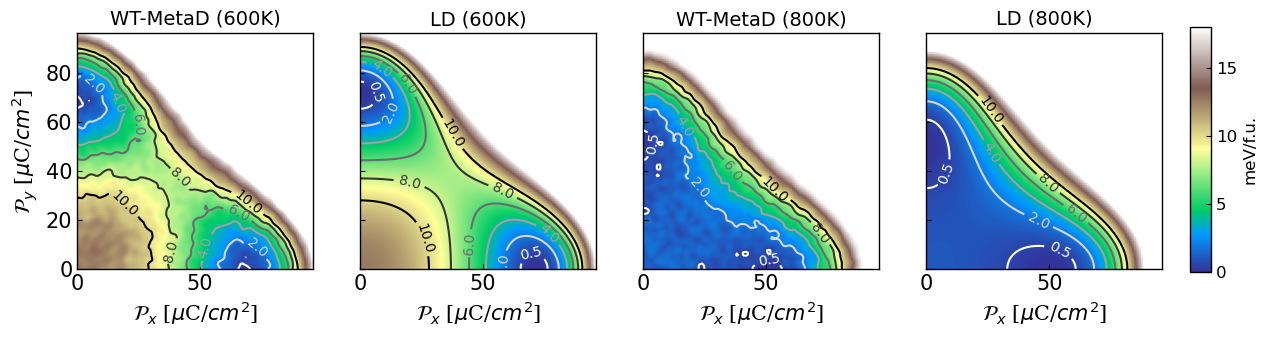

In [5]:
############## plot fitted potential vs real potential ############################
arr_F = np.load('FES_yz_all_temp.npy')
nbins = 101
all_temp = [ 300, 600,700,800,820,900,1000]
xlim = 0.06 * e2uC / Atcm**2
ylim = 0.06 * e2uC / Atcm**2
arr_F = arr_F.reshape(len(all_temp),-1,nbins,nbins)
print(arr_F.shape)
####### PREPARE grids
gridx = np.arange(nbins)/nbins
gridy = np.arange(nbins)/nbins
X,Y = np.meshgrid(gridx, gridy)
vmin = 0
vmax = 18
####### PLOT the comparison
fig, ax  = plt.subplots(1,4, figsize=(14, 3.5), sharex=True, sharey=True )
levels = [ 0.5, 2 ,4,6 ,8,10,]
for fig_idx, temp_idx in enumerate([1,3]):
    temp = all_temp[temp_idx]
    
    ## plot numerical results first
    F = arr_F[temp_idx,-1]
    F -= F.min()
    ax[temp_idx-1].imshow(F,
        cmap=cm.terrain,
        interpolation='antialiased',
        vmin=vmin,
        vmax=vmax,
        origin='lower',
        extent=(0,xlim,0,ylim)
        )
    CS = ax[temp_idx-1].contour(X*xlim,Y*ylim, F, linewidths=1.5,levels=levels, cmap='binary')
    ax[temp_idx-1].clabel(CS, CS.levels, inline=True,  fontsize=10)
    
    ## then compute fitted results
    px ,py, pz = X.flatten(),Y.flatten(),(0*X).flatten()
    M = []
    M.append(px**2 + py**2 + pz**2)  # a1
    M.append(px**4 + py**4 + pz**4)  # a11
    M.append(px**2*py**2 + px**2*pz**2 + py**2*pz**2) #a12
    M.append(px**6 + py**6 + pz**6)  #a111
    M.append(px**4*(py**2+pz**2) + py**4*(pz**2+px**2) + pz**4*(px**2+py**2)) # a112
    M.append(px**2*py**2*pz**2)  #a123
    ## lazy workaround for getting rid of redundancy in the zero of energy
    M.append(np.ones_like(px))
    M.append(np.ones_like(px)* (temp/1000)**norder) 
    M.append(np.ones_like(px)* (temp/1000)**(norder*2)) 
    nterms = len(M)
    M = np.array(M).reshape(nterms,-1).transpose()   ## (#data,#poly terms)
    temp_powered = np.array([temp**n for n in range(norder)])
    M = M[...,None] * temp_powered[None,None,:]  ## (#data,#poly terms * norder)
    M = M.reshape(-1, nterms * norder)
    fes_fitted = (M * coef[None,:]).sum(-1).reshape(X.shape)
    fes_fitted -= fes_fitted.min()
    fes_fitted = np.clip(fes_fitted, a_min=None,a_max=F.max())  ## cut off unfitted area
    im=ax[temp_idx].imshow(fes_fitted,
        # cmap='RdGy', 
        cmap=cm.terrain,
        interpolation='antialiased',
        # alpha=0.75,
        vmin=vmin,
        vmax=vmax,
        origin='lower',
        extent=(0,xlim,0,ylim)
        )
    
    CS = ax[temp_idx].contour(X*xlim,Y*ylim, fes_fitted, linewidths=1.5,levels=levels, cmap='binary')
    ax[temp_idx].clabel(CS, CS.levels, inline=True,  fontsize=10)

for _ax in ax:
    _ax.set_xlabel(r'$\mathcal{P}_x$ [$\mu$C/$cm^2$]',fontdict=font)
ax[0].set_ylabel(r'$\mathcal{P}_y$ [$\mu$C/$cm^2$]',fontdict=font)
ax[0].set_title('WT-MetaD (600K)', fontsize=14)
ax[1].set_title('LD (600K)', fontsize=14)
ax[2].set_title('WT-MetaD (800K)', fontsize=14)
ax[3].set_title('LD (800K)', fontsize=14)
# Add single colorbar on the right
plt.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar.ax.tick_params(labelsize=12)
cbar.set_label('meV/f.u.', fontsize=12)
# plt.tight_layout()
plt.savefig(os.path.join('FES_Landau_compare.png' ), dpi=300)
# plt.close(fig)